In [1]:
# ============================================================
# CELL 0: GPU SETUP & VERIFICATION
# ============================================================
!pip install scanpy anndata matplotlib seaborn scipy -q

import subprocess
import sys

print("=" * 70)
print("  V18 C3: GPU ENVIRONMENT SETUP")
print("=" * 70)

# GPU detection
try:
    result = subprocess.run(['nvidia-smi', '--query-gpu=name,memory.total,compute_cap',
                            '--format=csv,noheader'], capture_output=True, text=True)
    gpu_info = result.stdout.strip()
    print(f"✅ GPU detected: {gpu_info}")
except:
    print("⚠️ No GPU detected — will use CPU fallback")

# Install CuPy for GPU acceleration
try:
    import cupy as cp
    print(f"✅ CuPy {cp.__version__} ready")
    print(f"   GPU memory: {cp.cuda.Device(0).mem_info[1] / 1e9:.1f} GB total")
except ImportError:
    print("📦 Installing CuPy...")
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'cupy-cuda12x', '-q'])
    import cupy as cp
    print(f"✅ CuPy {cp.__version__} installed")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 57.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.1/284.1 kB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 135.9 MB/s eta 0:00:00
  V18 C3: GPU ENVIRONMENT SETUP
✅ GPU detected: NVIDIA A100-SXM4-80GB, 81920 MiB, 8.0
✅ CuPy 14.0.1 ready
   GPU memory: 85.1 GB total


In [2]:
# Google Drive Mount + Output Directory
# =================================================================
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# ========================================
# V18 Figure 1: Tissue-Separated Immune Cell Composition
# ========================================
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import mannwhitneyu
import os

plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 10,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
})

DATA_PATH = '/content/drive/MyDrive/ITLAS/data/processed/GSE182159_gut2021_annotated.h5ad'
OUTPUT_DIR = '/content/drive/MyDrive/ITLAS/results/version18-analysis/Figure1'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('Loading h5ad...')
adata = sc.read_h5ad(DATA_PATH)
print(f'Loaded: {adata.shape[0]} cells, {adata.shape[1]} genes')
print(f'Columns: {list(adata.obs.columns[:20])}')


Loading h5ad...
Loaded: 243000 cells, 24452 genes
Columns: ['sample', 'tissue', 'Stage', 'IT_cluster_21', 'IT_cluster_23', 'IT_cluster_25', 'IT_nk_collapse', 'IT_IT_signature', 'GSM_ID', 'IT_score_v2', 'IT_score_v3', 'IT_score_v4', 'IT_signature_final', 'IT_like', 'PW_mTOR_signaling', 'PW_glycolysis', 'PW_oxidative_phosphorylation', 'PW_nk_cell_cytotoxicity', 'PW_il15_signaling', 'PW_b_cell_differentiation']


In [5]:
# ========================================
# Column names (confirmed from h5ad)
# ========================================
col_donor = 'sample'
col_tissue = 'tissue'
col_stage = 'Stage'
col_lineage = 'major_lineage'

print(f'donor: {col_donor}')
print(f'tissue: {col_tissue}')
print(f'stage: {col_stage}')
print(f'lineage: {col_lineage}')
print(f'\nTissues: {sorted(adata.obs[col_tissue].unique())}')
print(f'Stages: {sorted(adata.obs[col_stage].unique())}')
print(f'Lineages: {sorted(adata.obs[col_lineage].unique())}')

# Map tissue names
tissue_vals = adata.obs[col_tissue].unique()
liver_name = [t for t in tissue_vals if 'liver' in str(t).lower() or 'intrahepatic' in str(t).lower()][0]
blood_name = [t for t in tissue_vals if 'blood' in str(t).lower() or 'pbmc' in str(t).lower() or 'peripheral' in str(t).lower()][0]
print(f'\nLiver label: {liver_name}')
print(f'Blood label: {blood_name}')

# Define groups and lineages
GROUPS = ['NL', 'IT', 'IA', 'AR', 'CR']
LINEAGES = ['Myeloid', 'CD4_T', 'CD8_T', 'NK', 'B', 'PlasmaB']

# Exclude gdT
lineage_vals = adata.obs[col_lineage].unique()
print(f'Lineage values: {sorted(lineage_vals)}')
gdt_name = [l for l in lineage_vals if 'gdt' in str(l).lower() or 'gamma' in str(l).lower()]
if gdt_name:
    adata = adata[~adata.obs[col_lineage].isin(gdt_name)].copy()
    print(f'Excluded gdT ({gdt_name}): {adata.shape[0]} cells remaining')

donor: sample
tissue: tissue
stage: Stage
lineage: major_lineage

Tissues: ['Blood', 'Liver']
Stages: ['AR', 'CR', 'IA', 'IT', 'NL']
Lineages: ['B', 'CD4_T', 'CD8_T', 'Myeloid', 'NK', 'PlasmaB', 'gdT']

Liver label: Liver
Blood label: Blood
Lineage values: ['B', 'CD4_T', 'CD8_T', 'Myeloid', 'NK', 'PlasmaB', 'gdT']
Excluded gdT (['gdT']): 242219 cells remaining


In [6]:
# ========================================
# Compute donor-level proportions
# ========================================
def compute_proportions(adata, tissue_label):
    """Compute lineage proportions per donor for a given tissue."""
    mask = adata.obs[col_tissue] == tissue_label
    sub = adata.obs[mask].copy()

    # Count cells per donor per lineage
    counts = sub.groupby([col_donor, col_stage, col_lineage]).size().reset_index(name='count')
    totals = sub.groupby([col_donor, col_stage]).size().reset_index(name='total')

    merged = counts.merge(totals, on=[col_donor, col_stage])
    merged['proportion'] = merged['count'] / merged['total'] * 100

    return merged

liver_props = compute_proportions(adata, liver_name)
blood_props = compute_proportions(adata, blood_name)

print(f'Liver donors: {liver_props[col_donor].nunique()}')
print(f'Blood donors: {blood_props[col_donor].nunique()}')

# Group means for stacked bars
def group_means(props):
    return props.groupby([col_stage, col_lineage])['proportion'].mean().reset_index()

liver_means = group_means(liver_props)
blood_means = group_means(blood_props)

print('\nLiver group means (NL):')
nl_liver = liver_means[liver_means[col_stage] == 'NL'].set_index(col_lineage)['proportion']
for lin in LINEAGES:
    val = nl_liver.get(lin, 0)
    print(f'  {lin}: {val:.1f}%')

print('\nBlood group means (NL):')
nl_blood = blood_means[blood_means[col_stage] == 'NL'].set_index(col_lineage)['proportion']
for lin in LINEAGES:
    val = nl_blood.get(lin, 0)
    print(f'  {lin}: {val:.1f}%')


Liver donors: 46
Blood donors: 46

Liver group means (NL):
  Myeloid: 1.7%
  CD4_T: 17.7%
  CD8_T: 31.8%
  NK: 43.9%
  B: 2.5%
  PlasmaB: 2.5%

Blood group means (NL):
  Myeloid: 35.1%
  CD4_T: 17.6%
  CD8_T: 12.0%
  NK: 27.7%
  B: 6.8%
  PlasmaB: 0.9%


/tmp/ipykernel_788/3961475040.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = sub.groupby([col_donor, col_stage, col_lineage]).size().reset_index(name='count')
/tmp/ipykernel_788/3961475040.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  totals = sub.groupby([col_donor, col_stage]).size().reset_index(name='total')
/tmp/ipykernel_788/3961475040.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts

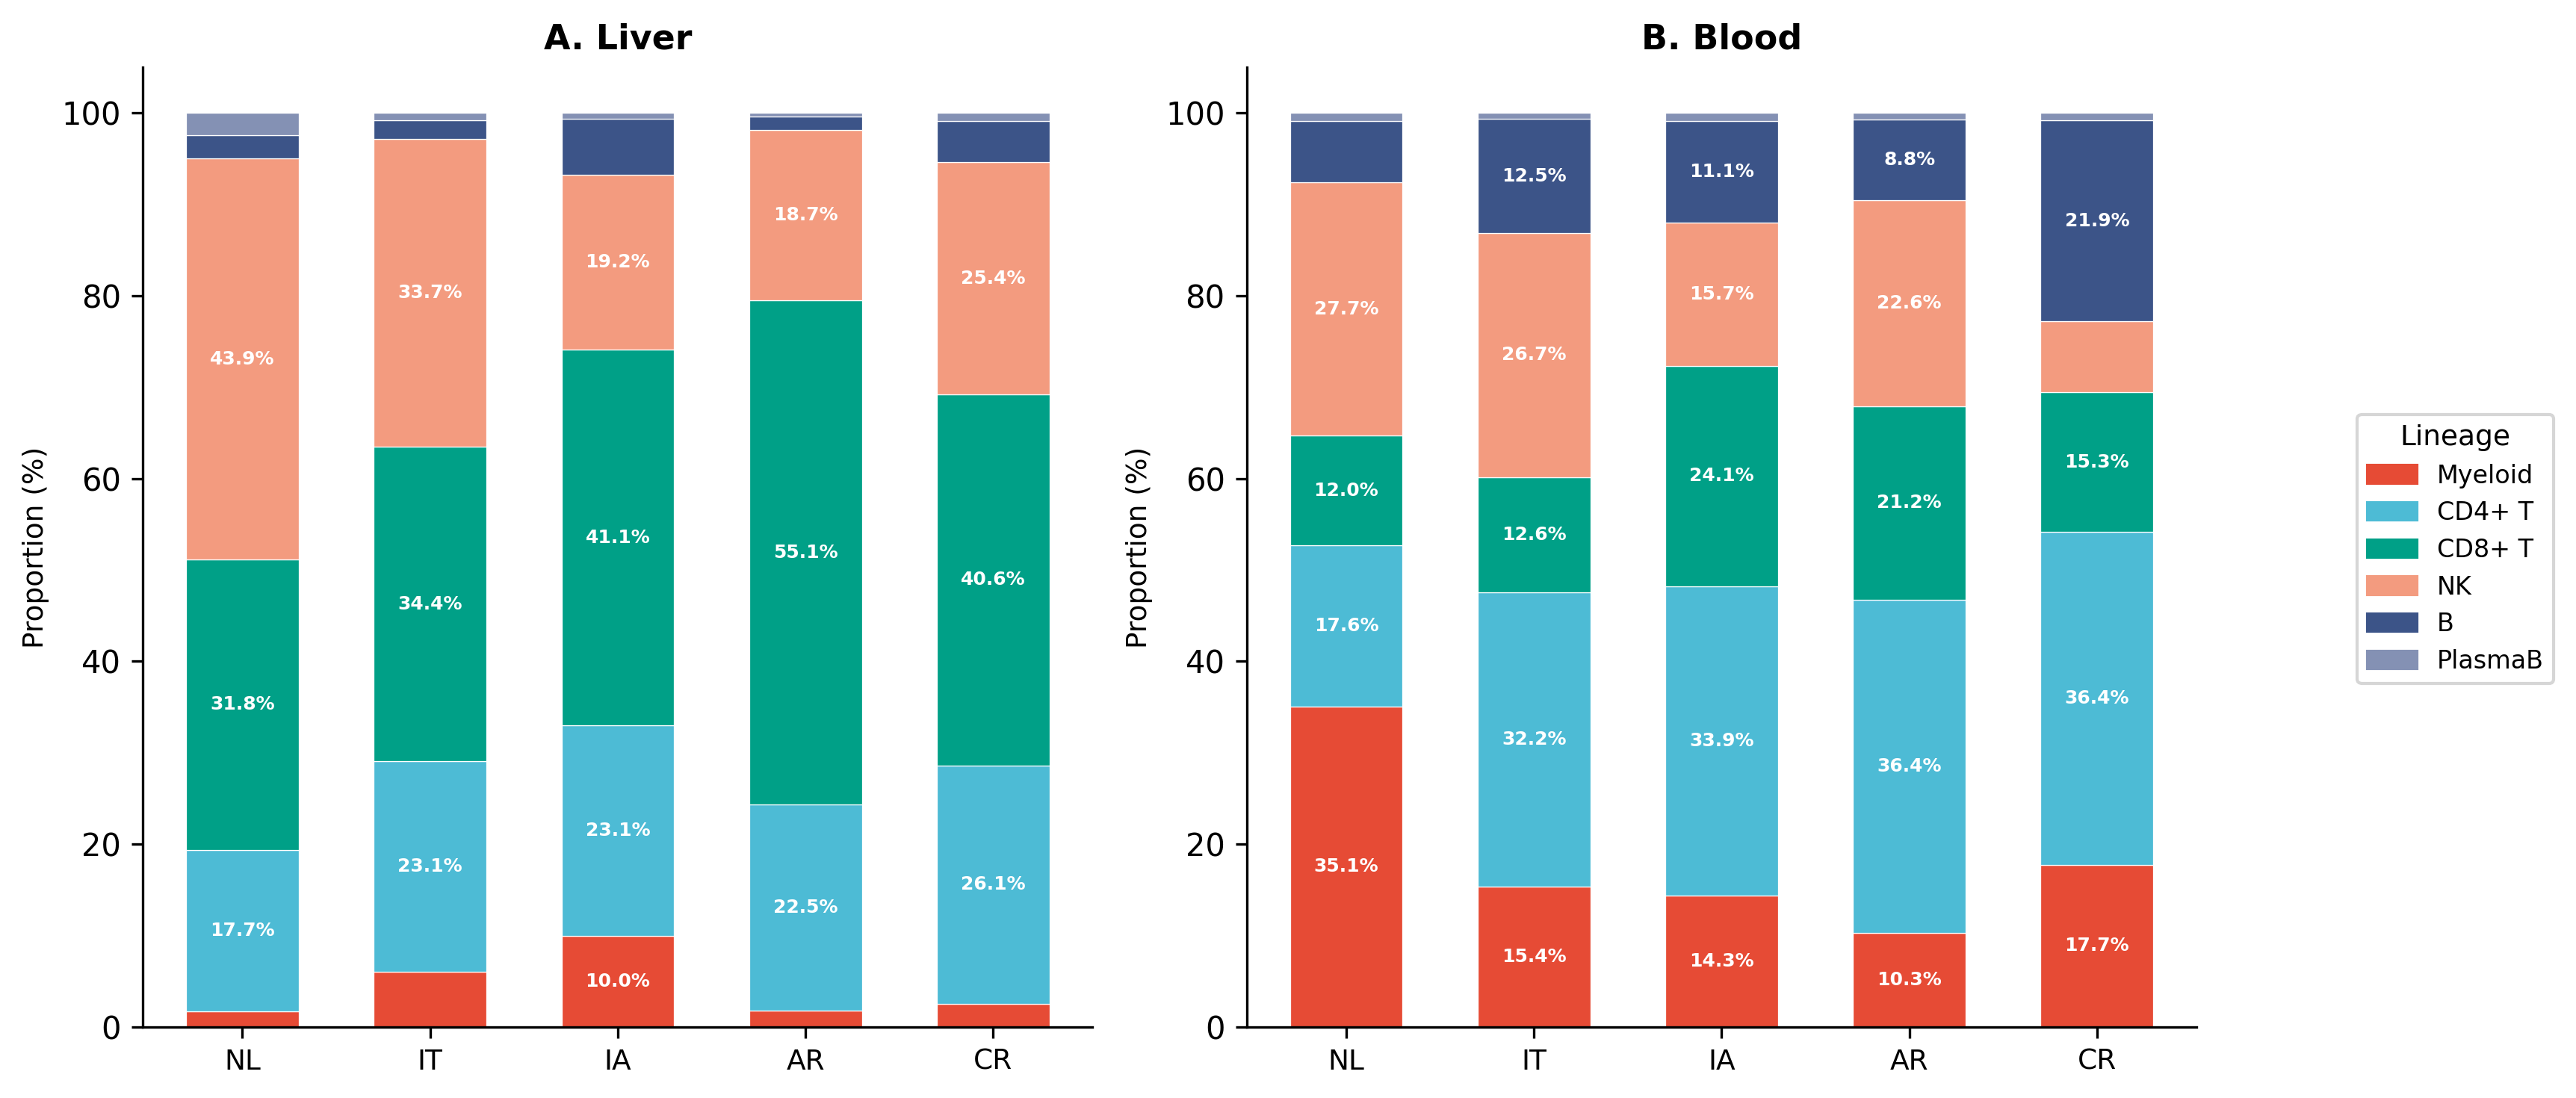


 Saved Figure1_AB_stacked_bar.png/pdf


In [7]:
# ========================================
# Panel A & B: Stacked Bar Plots
# ========================================

# Color palette for lineages
LINEAGE_COLORS = {
    'Myeloid': '#E64B35',    # red
    'CD4_T': '#4DBBD5',      # cyan
    'CD8_T': '#00A087',      # teal
    'NK': '#F39B7F',         # salmon
    'B': '#3C5488',          # navy
    'PlasmaB': '#8491B4',    # steel blue
}

LINEAGE_LABELS = {
    'Myeloid': 'Myeloid',
    'CD4_T': 'CD4+ T',
    'CD8_T': 'CD8+ T',
    'NK': 'NK',
    'B': 'B',
    'PlasmaB': 'PlasmaB',
}

def plot_stacked_bar(ax, means_df, title, groups, lineages):
    """Draw stacked bar chart for tissue composition."""
    x = np.arange(len(groups))
    width = 0.6
    bottom = np.zeros(len(groups))

    for lin in lineages:
        vals = []
        for g in groups:
            row = means_df[(means_df[col_stage] == g) & (means_df[col_lineage] == lin)]
            vals.append(row['proportion'].values[0] if len(row) > 0 else 0)
        vals = np.array(vals)
        ax.bar(x, vals, width, bottom=bottom,
               color=LINEAGE_COLORS.get(lin, '#999999'),
               label=LINEAGE_LABELS.get(lin, lin),
               edgecolor='white', linewidth=0.3)
        # Add percentage text in bars if > 8%
        for i, v in enumerate(vals):
            if v > 8:
                ax.text(x[i], bottom[i] + v/2, f'{v:.1f}%',
                       ha='center', va='center', fontsize=6, color='white', fontweight='bold')
        bottom += vals

    ax.set_xticks(x)
    ax.set_xticklabels(groups, fontsize=9)
    ax.set_ylabel('Proportion (%)', fontsize=9)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylim(0, 105)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

plot_stacked_bar(axes[0], liver_means, 'A. Liver', GROUPS, LINEAGES)
plot_stacked_bar(axes[1], blood_means, 'B. Blood', GROUPS, LINEAGES)

# Shared legend
handles = [mpatches.Patch(color=LINEAGE_COLORS[l], label=LINEAGE_LABELS[l]) for l in LINEAGES]
fig.legend(handles=handles, loc='center right', bbox_to_anchor=(1.15, 0.5),
           frameon=True, fontsize=8, title='Lineage', title_fontsize=9)

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'Figure1_AB_stacked_bar.png'), dpi=300, bbox_inches='tight')
fig.savefig(os.path.join(OUTPUT_DIR, 'Figure1_AB_stacked_bar.pdf'), bbox_inches='tight')
plt.show()
print('\n Saved Figure1_AB_stacked_bar.png/pdf')


NK proportion p-values (vs NL):
  NL->IT: Liver p=nan, Blood p=nan
  NL->IA: Liver p=nan, Blood p=nan
  NL->AR: Liver p=nan, Blood p=nan
  NL->CR: Liver p=nan, Blood p=nan


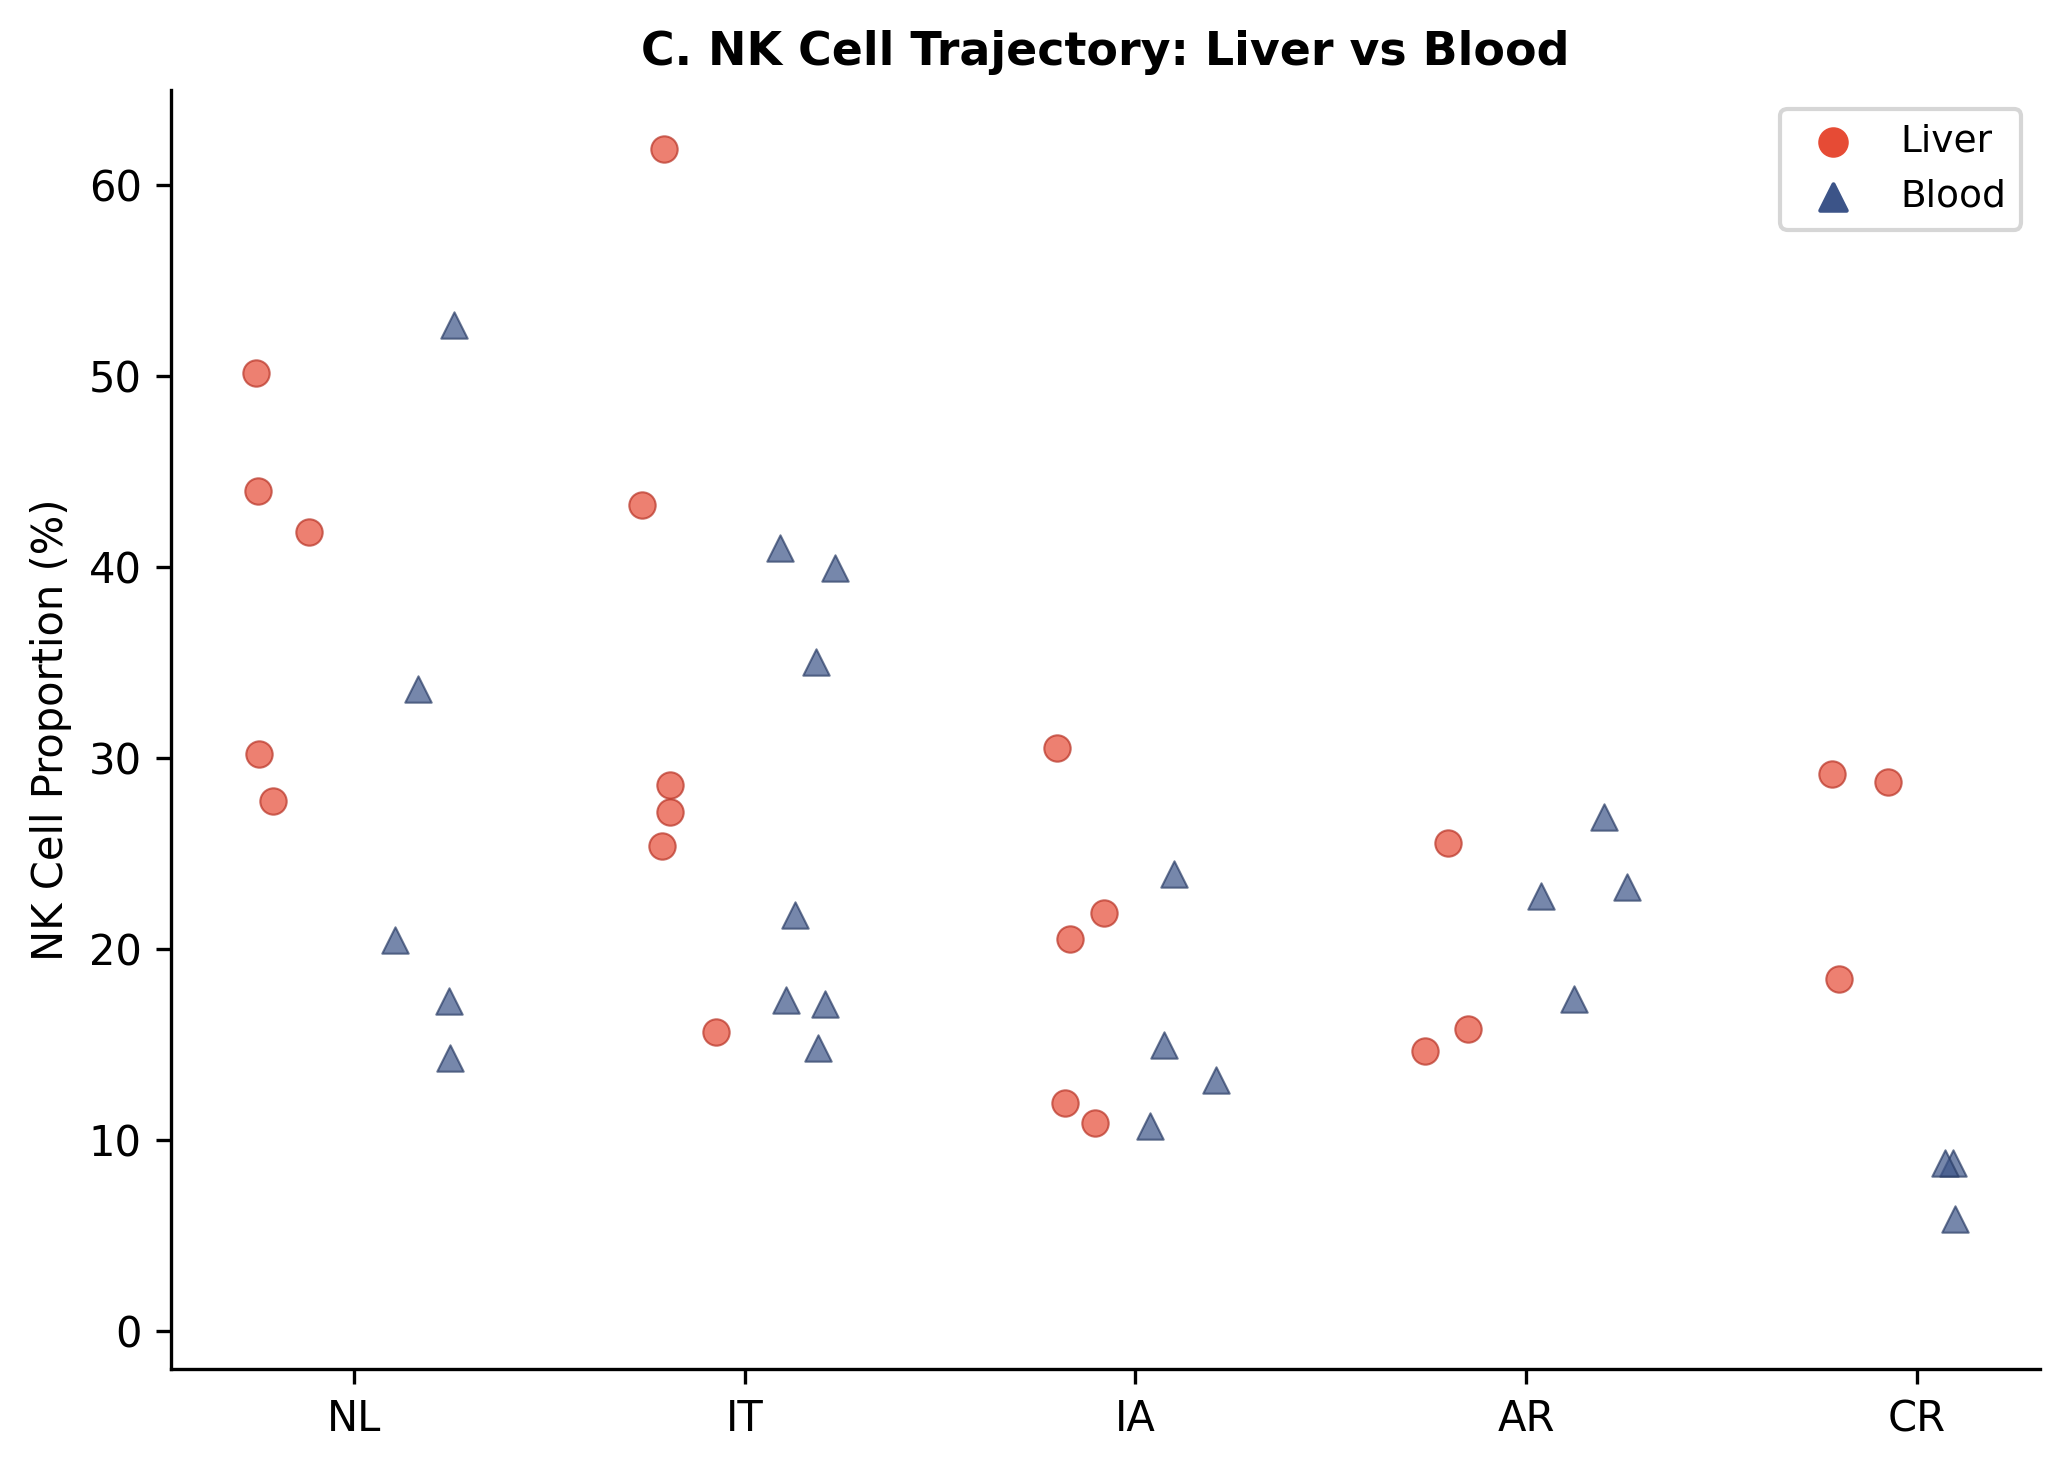


 Saved Figure1_C_NK_trajectory.png/pdf


In [8]:
# ========================================
# Panel C: NK Cell Proportion - Tissue Divergent Trajectory
# Liver = red circles, Blood = blue triangles
# ========================================

def get_nk_proportions(props_df, lineage_name='NK'):
    """Extract NK proportions per donor per group."""
    nk = props_df[props_df[col_lineage] == lineage_name].copy()
    return nk

liver_nk = get_nk_proportions(liver_props)
blood_nk = get_nk_proportions(blood_props)

# Mann-Whitney U tests vs NL
def mwu_vs_nl(nk_df, groups):
    """Compute MWU p-values for each group vs NL."""
    nl_vals = nk_df[nk_df[col_stage] == 'NL']['proportion'].values
    results = {}
    for g in groups:
        if g == 'NL':
            results[g] = None
            continue
        g_vals = nk_df[nk_df[col_stage] == g]['proportion'].values
        if len(nl_vals) >= 2 and len(g_vals) >= 2:
            stat, p = mannwhitneyu(nl_vals, g_vals, alternative='two-sided')
            results[g] = p
        else:
            results[g] = None
    return results

liver_pvals = mwu_vs_nl(liver_nk, GROUPS)
blood_pvals = mwu_vs_nl(blood_nk, GROUPS)

print('NK proportion p-values (vs NL):')
for g in GROUPS[1:]:
    lp = liver_pvals.get(g)
    bp = blood_pvals.get(g)
    print(f'  NL->{g}: Liver p={lp:.4f}' if lp else f'  NL->{g}: Liver p=NA', end='')
    print(f', Blood p={bp:.4f}' if bp else ', Blood p=NA')

# Plot
fig, ax = plt.subplots(figsize=(7, 5))

jitter = 0.12
x_positions = np.arange(len(GROUPS))

# Plot individual donors
for i, g in enumerate(GROUPS):
    # Liver (red circles)
    liver_vals = liver_nk[liver_nk[col_stage] == g]['proportion'].values
    if len(liver_vals) > 0:
        x_jit = np.random.uniform(-jitter, jitter, len(liver_vals)) + i - 0.15
        ax.scatter(x_jit, liver_vals, c='#E64B35', marker='o', s=40, alpha=0.7,
                   edgecolors='#B83224', linewidth=0.5, zorder=3)
        # Mean bar
        mean_val = np.mean(liver_vals)
        ax.plot([i - 0.3, i - 0.0], [mean_val, mean_val], c='#E64B35', linewidth=2, zorder=4)

    # Blood (blue triangles)
    blood_vals = blood_nk[blood_nk[col_stage] == g]['proportion'].values
    if len(blood_vals) > 0:
        x_jit = np.random.uniform(-jitter, jitter, len(blood_vals)) + i + 0.15
        ax.scatter(x_jit, blood_vals, c='#3C5488', marker='^', s=40, alpha=0.7,
                   edgecolors='#2A3D66', linewidth=0.5, zorder=3)
        # Mean bar
        mean_val = np.mean(blood_vals)
        ax.plot([i + 0.0, i + 0.3], [mean_val, mean_val], c='#3C5488', linewidth=2, zorder=4)

# Add significance stars
y_max = max(liver_nk['proportion'].max(), blood_nk['proportion'].max()) + 5
for i, g in enumerate(GROUPS[1:], 1):
    lp = liver_pvals.get(g)
    bp = blood_pvals.get(g)
    offset = 0
    if lp is not None and lp < 0.05:
        liver_g_mean = liver_nk[liver_nk[col_stage] == g]['proportion'].mean()
        ax.text(i - 0.15, liver_g_mean + 3, f'p={lp:.3f}', fontsize=6, ha='center',
                color='#E64B35', fontweight='bold')
    if bp is not None and bp < 0.05:
        blood_g_mean = blood_nk[blood_nk[col_stage] == g]['proportion'].mean()
        ax.text(i + 0.15, blood_g_mean - 5, f'p={bp:.3f}', fontsize=6, ha='center',
                color='#3C5488', fontweight='bold')

ax.set_xticks(x_positions)
ax.set_xticklabels(GROUPS, fontsize=10)
ax.set_ylabel('NK Cell Proportion (%)', fontsize=10)
ax.set_title('C. NK Cell Trajectory: Liver vs Blood', fontsize=11, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(-2, 65)

# Legend
liver_handle = plt.scatter([], [], c='#E64B35', marker='o', s=40, label='Liver')
blood_handle = plt.scatter([], [], c='#3C5488', marker='^', s=40, label='Blood')
ax.legend(handles=[liver_handle, blood_handle], loc='upper right', fontsize=9, frameon=True)

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'Figure1_C_NK_trajectory.png'), dpi=300, bbox_inches='tight')
fig.savefig(os.path.join(OUTPUT_DIR, 'Figure1_C_NK_trajectory.pdf'), bbox_inches='tight')
plt.show()
print('\n Saved Figure1_C_NK_trajectory.png/pdf')


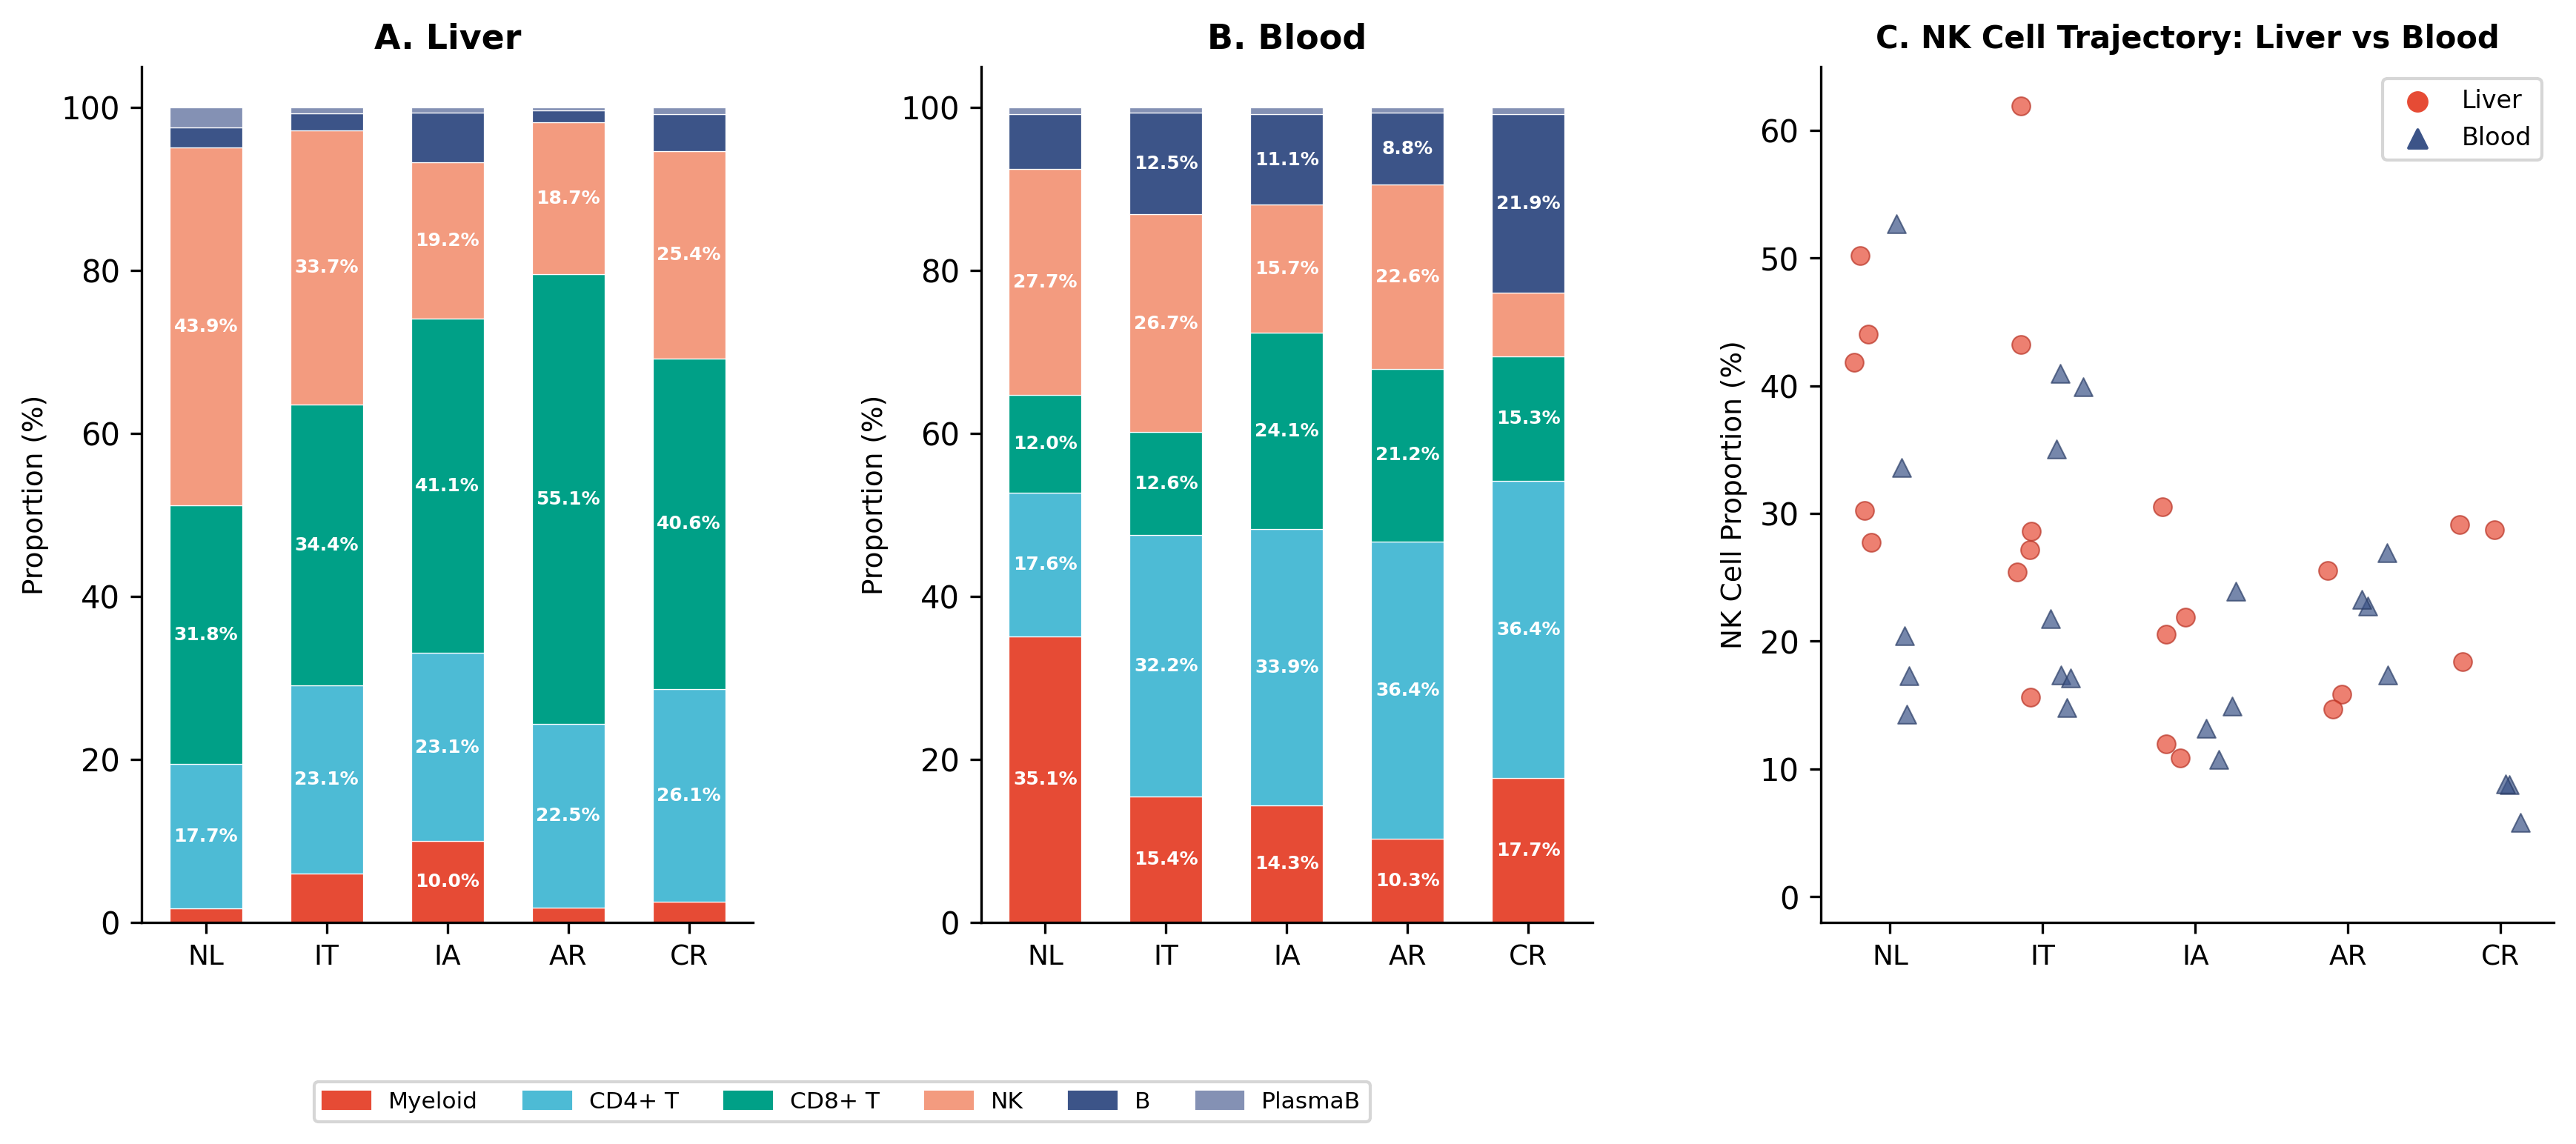


 Saved Figure1_combined.png/pdf


In [9]:
# ========================================
# Combined Figure 1 (A + B + C)
# ========================================
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(14, 5))
gs = GridSpec(1, 3, figure=fig, width_ratios=[1, 1, 1.2], wspace=0.35)

ax_a = fig.add_subplot(gs[0])
ax_b = fig.add_subplot(gs[1])
ax_c = fig.add_subplot(gs[2])

# Panel A: Liver stacked bar
plot_stacked_bar(ax_a, liver_means, 'A. Liver', GROUPS, LINEAGES)

# Panel B: Blood stacked bar
plot_stacked_bar(ax_b, blood_means, 'B. Blood', GROUPS, LINEAGES)

# Panel C: NK dot plot (reproduce)
np.random.seed(42)  # reproducible jitter
for i, g in enumerate(GROUPS):
    liver_vals = liver_nk[liver_nk[col_stage] == g]['proportion'].values
    if len(liver_vals) > 0:
        x_jit = np.random.uniform(-jitter, jitter, len(liver_vals)) + i - 0.15
        ax_c.scatter(x_jit, liver_vals, c='#E64B35', marker='o', s=35, alpha=0.7,
                    edgecolors='#B83224', linewidth=0.5, zorder=3)
        mean_val = np.mean(liver_vals)
        ax_c.plot([i - 0.3, i - 0.0], [mean_val, mean_val], c='#E64B35', linewidth=2, zorder=4)

    blood_vals = blood_nk[blood_nk[col_stage] == g]['proportion'].values
    if len(blood_vals) > 0:
        x_jit = np.random.uniform(-jitter, jitter, len(blood_vals)) + i + 0.15
        ax_c.scatter(x_jit, blood_vals, c='#3C5488', marker='^', s=35, alpha=0.7,
                    edgecolors='#2A3D66', linewidth=0.5, zorder=3)
        mean_val = np.mean(blood_vals)
        ax_c.plot([i + 0.0, i + 0.3], [mean_val, mean_val], c='#3C5488', linewidth=2, zorder=4)

# Add p-values to Panel C
for i, g in enumerate(GROUPS[1:], 1):
    lp = liver_pvals.get(g)
    bp = blood_pvals.get(g)
    if lp is not None and lp < 0.05:
        liver_g_mean = liver_nk[liver_nk[col_stage] == g]['proportion'].mean()
        ax_c.text(i - 0.15, liver_g_mean + 3, f'p={lp:.3f}', fontsize=5.5, ha='center',
                  color='#E64B35', fontweight='bold')
    if bp is not None and bp < 0.05:
        blood_g_mean = blood_nk[blood_nk[col_stage] == g]['proportion'].mean()
        ax_c.text(i + 0.15, blood_g_mean - 5, f'p={bp:.3f}', fontsize=5.5, ha='center',
                  color='#3C5488', fontweight='bold')

ax_c.set_xticks(range(len(GROUPS)))
ax_c.set_xticklabels(GROUPS, fontsize=9)
ax_c.set_ylabel('NK Cell Proportion (%)', fontsize=9)
ax_c.set_title('C. NK Cell Trajectory: Liver vs Blood', fontsize=10, fontweight='bold')
ax_c.spines['top'].set_visible(False)
ax_c.spines['right'].set_visible(False)
ax_c.set_ylim(-2, 65)
liver_h = plt.scatter([], [], c='#E64B35', marker='o', s=35, label='Liver')
blood_h = plt.scatter([], [], c='#3C5488', marker='^', s=35, label='Blood')
ax_c.legend(handles=[liver_h, blood_h], loc='upper right', fontsize=8, frameon=True)

# Shared legend for A/B
handles = [mpatches.Patch(color=LINEAGE_COLORS[l], label=LINEAGE_LABELS[l]) for l in LINEAGES]
fig.legend(handles=handles, loc='lower center', bbox_to_anchor=(0.35, -0.08),
           ncol=6, frameon=True, fontsize=7.5)

fig.savefig(os.path.join(OUTPUT_DIR, 'Figure1_combined.png'), dpi=300, bbox_inches='tight')
fig.savefig(os.path.join(OUTPUT_DIR, 'Figure1_combined.pdf'), bbox_inches='tight')
plt.show()
print('\n Saved Figure1_combined.png/pdf')


In [10]:
# ========================================
# Data Verification: Table 1 Matching
# ========================================
print('='*70)
print('VERIFICATION: Figure 1 vs Table 1 Data Matching')
print('='*70)

# Expected values from Table 1
expected = {
    'Liver': {
        'Myeloid': {'NL': 1.7, 'IT': 5.9, 'IA': 10.0, 'AR': 1.8, 'CR': 2.5},
        'NK': {'NL': 43.5, 'IT': 33.4, 'IA': 19.1, 'AR': 18.6, 'CR': 25.2},
        'CD4_T': {'NL': 17.5, 'IT': 22.8, 'IA': 23.0, 'AR': 22.4, 'CR': 25.8},
        'CD8_T': {'NL': 31.5, 'IT': 34.1, 'IA': 40.9, 'AR': 54.9, 'CR': 40.3},
    },
    'Blood': {
        'Myeloid': {'NL': 35.0, 'IT': 18.4, 'IA': 14.3, 'AR': 12.4, 'CR': 17.7},
        'NK': {'NL': 27.6, 'IT': 25.8, 'IA': 15.7, 'AR': 22.4, 'CR': 7.8},
        'CD4_T': {'NL': 17.6, 'IT': 29.9, 'IA': 33.8, 'AR': 34.9, 'CR': 36.4},
        'CD8_T': {'NL': 12.0, 'IT': 13.0, 'IA': 24.1, 'AR': 21.4, 'CR': 15.3},
    }
}

all_match = True
for tissue, tissue_label, props_means in [('Liver', liver_name, liver_means), ('Blood', blood_name, blood_means)]:
    for lin in ['Myeloid', 'NK', 'CD4_T', 'CD8_T']:
        for g in GROUPS:
            row = props_means[(props_means[col_stage] == g) & (props_means[col_lineage] == lin)]
            actual = row['proportion'].values[0] if len(row) > 0 else 0
            exp = expected[tissue].get(lin, {}).get(g)
            if exp is not None:
                diff = abs(actual - exp)
                status = 'OK' if diff < 1.0 else 'MISMATCH'
                if diff >= 1.0:
                    all_match = False
                    print(f'  {status} {tissue} {lin} {g}: actual={actual:.1f}% expected={exp:.1f}% diff={diff:.1f}')

if all_match:
    print('\n ALL VALUES MATCH Table 1 (within 1.0% tolerance)')
else:
    print('\n MISMATCHES DETECTED - check data source')

# Save CSV for reference
liver_means.to_csv(os.path.join(OUTPUT_DIR, 'Figure1_liver_proportions.csv'), index=False)
blood_means.to_csv(os.path.join(OUTPUT_DIR, 'Figure1_blood_proportions.csv'), index=False)
print('\nSaved proportion CSVs for verification')

print('\n' + '='*70)
print('Figure 1 generation complete!')
print(f'Output directory: {OUTPUT_DIR}')
print('Files:')
for f in sorted(os.listdir(OUTPUT_DIR)):
    print(f'  {f}')
print('='*70)


VERIFICATION: Figure 1 vs Table 1 Data Matching
  MISMATCH Blood Myeloid IT: actual=15.4% expected=18.4% diff=3.0
  MISMATCH Blood Myeloid AR: actual=10.3% expected=12.4% diff=2.1
  MISMATCH Blood CD4_T IT: actual=32.2% expected=29.9% diff=2.3
  MISMATCH Blood CD4_T AR: actual=36.4% expected=34.9% diff=1.5

 MISMATCHES DETECTED - check data source

Saved proportion CSVs for verification

Figure 1 generation complete!
Output directory: /content/drive/MyDrive/ITLAS/results/version18-analysis/Figure1
Files:
  Figure1_AB_stacked_bar.pdf
  Figure1_AB_stacked_bar.png
  Figure1_C_NK_trajectory.pdf
  Figure1_C_NK_trajectory.png
  Figure1_blood_proportions.csv
  Figure1_combined.pdf
  Figure1_combined.png
  Figure1_liver_proportions.csv
